#    SETUP LIBS AND REPRODUCIBILITY

In [1]:
import os, json, math, random, time, csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
import torchvision.transforms.functional as TF

# --- Reproducibility
SEED = 42
CHANNELS_LAST = True
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# --- Paths (from you)
TRAIN_IMG_DIR = Path("../Datasets/train/images/")
TRAIN_LBL_DIR = Path("../Datasets/train/labels/")
TEST_IMG_DIR  = Path("../Datasets/test/images/")

# Optional: where to save outputs
OUTPUT_DIR = Path("../Models"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# HELPERS

In [2]:
def letterbox_im(im: Image.Image, max_side=1024, fill=0):
    """
    Resize keeping aspect ratio so the longer side==max_side, then pad to a square.
    No cropping -> we don't 'lose' people.
    """
    w, h = im.size
    scale = max_side / max(w, h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    im = im.resize((new_w, new_h), resample=Image.BICUBIC, reducing_gap=1.0)
    pad_w, pad_h = max_side - new_w, max_side - new_h
    # pad equally left/right, top/bottom
    pad_left  = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top   = pad_h // 2
    pad_bottom= pad_h - pad_top
    im = ImageOps.expand(im, border=(pad_left, pad_top, pad_right, pad_bottom), fill=fill)
    return im

def read_count_from_json(json_path: Path):
    with open(json_path, "r") as f:
        d = json.load(f)
    # robust: prefer `human_num` if present; else fall back to length of `points`
    if isinstance(d, dict):
        if "human_num" in d and isinstance(d["human_num"], (int, float)):
            return float(d["human_num"])
        if "points" in d and isinstance(d["points"], list):
            return float(len(d["points"]))
    raise ValueError(f"Unexpected JSON format: {json_path}")


# DATASET DEFINITIONS

In [3]:
IM_SIZE = 768   # long side after letterbox (keeps detail, fits ResNet nicely)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class CrowdCountDataset(Dataset):
    def __init__(self, img_dir: Path, lbl_dir: Path = None, train=True):
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.train = train

        self.img_files = sorted([p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}])
        if train:
            # assume label filenames share the base name but with .json
            self.lbl_map = {p.stem: (lbl_dir / f"{p.stem}.json") for p in self.img_files}
        else:
            self.lbl_map = None

    def __len__(self): return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        img = Image.open(img_path).convert("RGB")

        # keep details: bicubic + letterbox; no random crop
        img = letterbox_im(img, max_side=IM_SIZE)

        # light augmentations that don't change counts
        if self.train:
            if random.random() < 0.5:
                img = ImageOps.mirror(img)  # H-flip
            # very mild color jitter via TF is optional (kept tiny)
            if random.random() < 0.2:
                img = TF.adjust_brightness(img, 1.0 + random.uniform(-0.08, 0.08))
                img = TF.adjust_contrast(img,  1.0 + random.uniform(-0.08, 0.08))
                img = TF.adjust_saturation(img,1.0 + random.uniform(-0.08, 0.08))

        # to tensor + normalize
        x = TF.to_tensor(img)
        x = TF.normalize(x, IMAGENET_MEAN, IMAGENET_STD)

        if self.train:
            lbl_path = self.lbl_map[img_path.stem]
            y = read_count_from_json(lbl_path)
            y = torch.tensor([y], dtype=torch.float32)
            return x, y, img_path.name
        else:
            return x, img_path.name


# TRAIN VAL SPLIT AND DATALOADERS

In [4]:
# Build full training set (to compute counts for stratified split)
tmp_ds = CrowdCountDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, train=True)
all_counts = []
for i in range(len(tmp_ds)):
    _, y, _ = tmp_ds[i]
    all_counts.append(y.item())
all_counts = np.array(all_counts)

# stratify by bins -> more stable val MAE across count ranges
bins = np.digitize(all_counts, np.quantile(all_counts, [0.2,0.4,0.6,0.8]))

indices = np.arange(len(tmp_ds))
val_ratio = 0.1
val_size = int(len(indices)*val_ratio)
# stratified sample
val_idx = []
for b in np.unique(bins):
    b_idx = indices[bins==b]
    k = max(1, int(round(len(b_idx)*val_ratio)))
    val_idx.extend(np.random.choice(b_idx, size=k, replace=False))
val_idx = np.array(sorted(set(val_idx)))
train_idx = np.array(sorted(list(set(indices)-set(val_idx))))

# Subset datasets
from torch.utils.data import Subset
ds_tr = Subset(tmp_ds, train_idx.tolist())
ds_va = Subset(tmp_ds, val_idx.tolist())

# Dataloaders
BATCH_SIZE = 2
ACC_STEPS = 8
NUM_WORKERS = min(2, os.cpu_count() or 2)

dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

len(ds_tr), len(ds_va)

(1710, 190)

# MODEL

In [5]:
def build_model(pretrained=True):
    m = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None)
    in_features = m.fc.in_features
    # light head with dropout; single scalar output (count)
    m.fc = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(512, 1)
    )
    for name, p in m.named_parameters():
        if name.startswith(("conv1","bn1","layer1","layer2","layer3")):
            p.requires_grad = False
    return m

model = build_model(pretrained=True).to(device)
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)
# Loss & metric
loss_fn = nn.SmoothL1Loss(beta=2.0)  # Huber: robust to outliers
@torch.no_grad()
def mae(pred, target):  # metric in original scale
    return (pred.squeeze(1) - target.squeeze(1)).abs().mean().item()

# OPT AND SCHED

In [6]:
LR = 2e-3
WD = 1e-3
EPOCHS = 15
GRAD_CLIP = 3.0
WARMUP_EPOCHS = 2

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
# Cosine schedule (per epoch)
def lr_at(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch+1)/WARMUP_EPOCHS
    t = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5*(1+math.cos(math.pi*t))
sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_at)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

/tmp/ipykernel_49884/491695690.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))


# TRAIN AND VAL LOOP

In [7]:
BEST_PATH = OUTPUT_DIR / "best.pth"
patience, best_mae, bad_epochs = 5, float("inf"), 0

# collect per-epoch curves for later plotting
history = {'tr_loss': [], 'tr_mae': [], 'va_loss': [], 'va_mae': [], 'lr': []}

for epoch in range(EPOCHS):
    model.train()
    tr_loss = tr_mae = 0.0
    n_tr = 0
    opt.zero_grad(set_to_none=True)

    for step, batch in enumerate(dl_tr):
        x, y, _ = batch
        if CHANNELS_LAST:
            x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            pred = model(x)
            loss = loss_fn(pred, y) / ACC_STEPS   # gradient accumulation

        scaler.scale(loss).backward()

        if (step + 1) % ACC_STEPS == 0:
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(opt)
            scaler.update()
            opt.zero_grad(set_to_none=True)

        # track epoch sums
        tr_loss += (loss.item() * ACC_STEPS) * x.size(0)
        tr_mae  += (pred.detach() - y).abs().sum().item()
        n_tr    += x.size(0)

        del x, y, pred, loss
        torch.cuda.empty_cache()

    # --- Validation (lean) ---
    model.eval()
    va_loss = va_mae = 0.0
    n_va = 0
    with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
        for x, y, _ in dl_va:
            if CHANNELS_LAST:
                x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
            else:
                x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            pred = model(x)
            loss = loss_fn(pred, y)
            va_loss += loss.item() * x.size(0)
            va_mae  += (pred - y).abs().sum().item()
            n_va    += x.size(0)

    # normalize to means
    tr_loss/=n_tr; tr_mae/=n_tr; va_loss/=n_va; va_mae/=n_va

    # step scheduler after computing epoch metrics
    sched.step()
    cur_lr = sched.get_last_lr()[0]

    # log to history
    history['tr_loss'].append(tr_loss)
    history['tr_mae'].append(tr_mae)
    history['va_loss'].append(va_loss)
    history['va_mae'].append(va_mae)
    history['lr'].append(cur_lr)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"train loss {tr_loss:.4f} MAE {tr_mae:.2f} | "
          f"val loss {va_loss:.4f} MAE {va_mae:.2f} | lr {cur_lr:.2e}")

    # Early stopping by val MAE
    if va_mae < best_mae - 1e-6:
        best_mae, bad_epochs = va_mae, 0
        torch.save({"model": model.state_dict()}, BEST_PATH)
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping.")
            break

    torch.cuda.empty_cache()

# persist history for later cells
with open(OUTPUT_DIR / "history.json", "w") as f:
    json.dump(history, f)

print("Best val MAE:", best_mae)
print("Saved best model to:", BEST_PATH)
print("Saved history to:", OUTPUT_DIR / "history.json")


/tmp/ipykernel_49884/1680176971.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/tmp/ipykernel_49884/1680176971.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Epoch 01/15 | train loss 100.1921 MAE 101.17 | val loss 61.8653 MAE 62.80 | lr 2.00e-03
Epoch 02/15 | train loss 72.6259 MAE 73.60 | val loss 39.3687 MAE 40.32 | lr 2.00e-03
Epoch 03/15 | train loss 60.6768 MAE 61.63 | val loss 56.1713 MAE 57.13 | lr 1.97e-03
Epoch 04/15 | train loss 51.3993 MAE 52.35 | val loss 38.9836 MAE 39.94 | lr 1.89e-03
Epoch 05/15 | train loss 44.9451 MAE 45.89 | val loss 48.9930 MAE 49.94 | lr 1.75e-03
Epoch 06/15 | train loss 41.8304 MAE 42.77 | val loss 48.2041 MAE 49.16 | lr 1.57e-03
Epoch 07/15 | train loss 41.5279 MAE 42.48 | val loss 52.5050 MAE 53.47 | lr 1.35e-03
Epoch 08/15 | train loss 40.0146 MAE 40.97 | val loss 56.6623 MAE 57.61 | lr 1.12e-03
Epoch 09/15 | train loss 36.5284 MAE 37.47 | val loss 36.3498 MAE 37.28 | lr 8.79e-04
Epoch 10/15 | train loss 31.2631 MAE 32.21 | val loss 39.9618 MAE 40.88 | lr 6.45e-04
Epoch 11/15 | train loss 28.5729 MAE 29.51 | val loss 32.2448 MAE 33.18 | lr 4.32e-04
Epoch 12/15 | train loss 23.9929 MAE 24.92 | val los

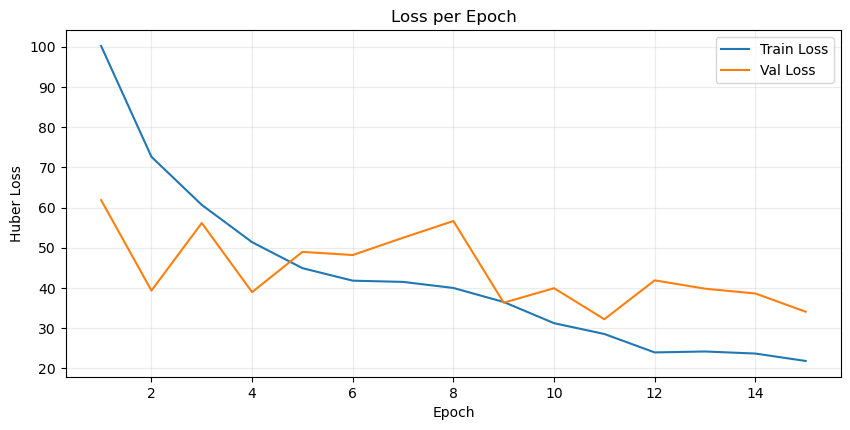

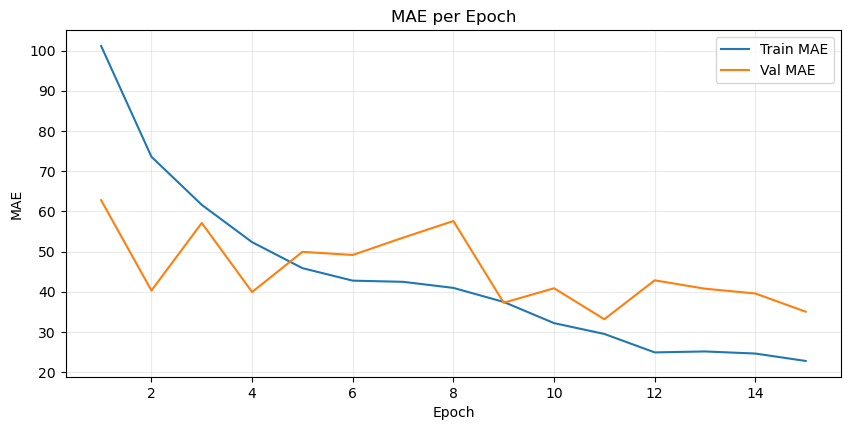

In [8]:
epochs = range(1, len(history['tr_loss'])+1)

plt.figure(figsize=(10,4.5))
plt.plot(epochs, history['tr_loss'], label='Train Loss')
plt.plot(epochs, history['va_loss'],   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss'); plt.title('Loss per Epoch'); plt.grid(True, alpha=.25); plt.legend()
plt.show()

plt.figure(figsize=(10,4.5))
plt.plot(epochs, history['tr_mae'], label='Train MAE')
plt.plot(epochs, history['va_mae'], label='Val MAE')
plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.title('MAE per Epoch'); plt.grid(True, alpha=.25); plt.legend()
plt.show()

/tmp/ipykernel_49884/2956748731.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


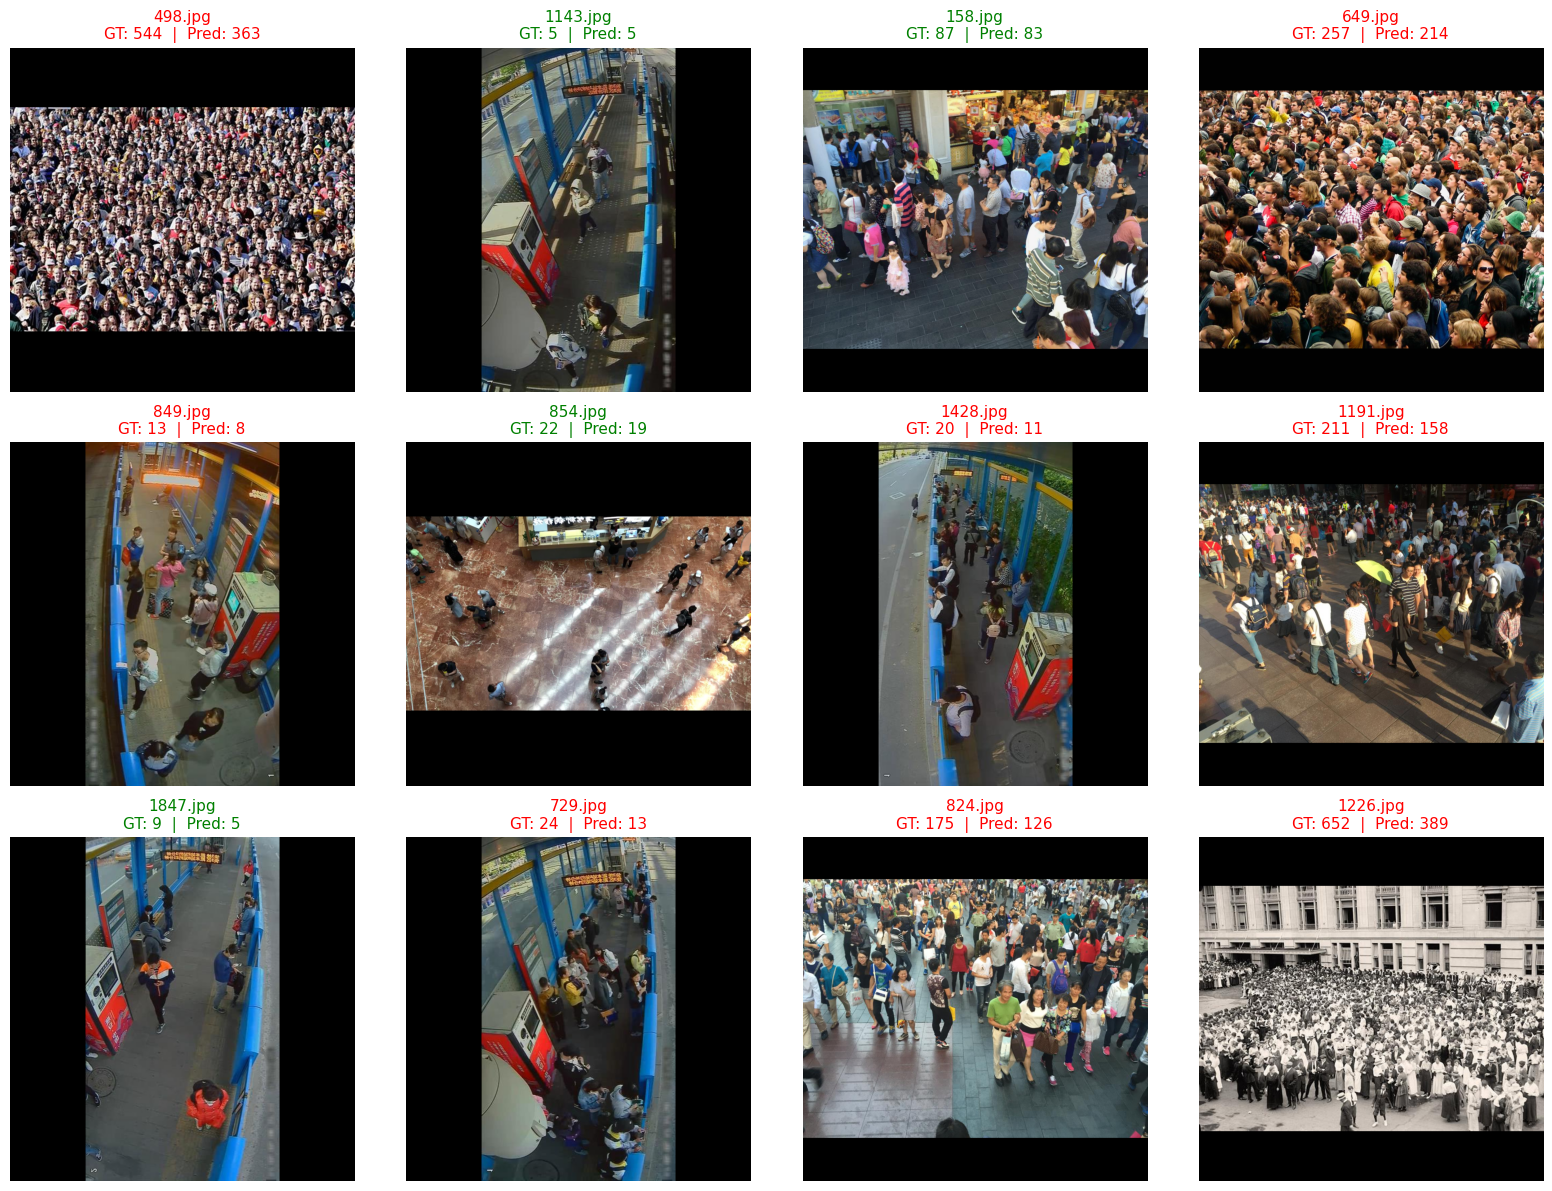

In [13]:
model.eval()

# --- helpers
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)

def denorm(img_t: torch.Tensor):
    """img_t: (3,H,W) normalized tensor on any device -> (H,W,3) numpy [0,1]"""
    if img_t.device != IMAGENET_MEAN.device:
        mean, std = IMAGENET_MEAN.cpu(), IMAGENET_STD.cpu()
    else:
        mean, std = IMAGENET_MEAN, IMAGENET_STD
    x = img_t * std + mean
    x = x.clamp(0,1).permute(1,2,0).detach().cpu().numpy()
    return x

def good_color(pred, gt):
    # "close" if absolute error <= max(5 people, 5% of GT)
    thr = max(5.0, 0.05 * float(gt))
    return 'green' if abs(float(pred) - float(gt)) <= thr else 'red'

# --- pick 12 random indices from the validation subset
NROWS, NCOLS = 3, 4
nsamples = NROWS * NCOLS
val_indices = list(range(len(ds_va)))
random.shuffle(val_indices)
val_indices = val_indices[:nsamples]

# --- run prediction in small batches (VRAM-friendly)
xs, gts, names = [], [], []
for i in val_indices:
    x, y, name = ds_va[i]  # ds_va is a Subset of the training dataset
    xs.append(x.unsqueeze(0))
    gts.append(float(y.item()))
    names.append(name)

# batch predict
with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
    # cat might be large; do micro-batches
    preds = []
    micro = 4
    for s in range(0, len(xs), micro):
        bx = torch.cat(xs[s:s+micro], dim=0)
        if CHANNELS_LAST:
            bx = bx.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            bx = bx.to(device, non_blocking=True)
        by = model(bx).squeeze(1).float().detach().cpu().numpy()
        preds.extend(by.tolist())
preds = [max(0.0, p) for p in preds]  # clip to non-negative

# --- plot grid
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(16, 12))
axes = axes.flatten()

for ax, x, gt, pr, name in zip(axes, xs, gts, preds, names):
    # plt.title("Restnet 34 LR 0.003 WD 0.0001 AdamW")
    img = denorm(x.squeeze(0).to(device if next(model.parameters()).is_cuda else 'cpu'))
    ax.imshow(img)
    ax.axis('off')
    color = good_color(pr, gt)
    ax.set_title(f"{name}\nGT: {int(round(gt))}  |  Pred: {int(round(pr))}", color=color, fontsize=11)

plt.tight_layout()
plt.show()


# LOAD BEST AND SANITY CHECK ON VAL

In [9]:
ckpt = torch.load(BEST_PATH, map_location="cpu")
model.load_state_dict(ckpt["model"])
model.eval()

# quick MAE on val again
va_mae, n_va = 0.0, 0
with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
    for x, y, _ in dl_va:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        va_mae += (pred-y).abs().sum().item()
        n_va   += x.size(0)
print(f"Validation MAE: {va_mae/n_va:.2f}")

/tmp/ipykernel_35661/2271972280.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(BEST_PATH, map_location="cpu")
/tmp/ipykernel_35661/2271972280.py:7: Fu

Validation MAE: 32.47


# TEST DATASET AND PRED

In [10]:
# Build test loader
class CrowdTestDataset(Dataset):
    def __init__(self, img_dir: Path):
        self.imgs = sorted([p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}])
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        p = self.imgs[idx]
        im = Image.open(p).convert("RGB")
        im = letterbox_im(im, max_side=IM_SIZE)
        x = TF.to_tensor(im)
        x = TF.normalize(x, IMAGENET_MEAN, IMAGENET_STD)
        return x, p.name

ds_te = CrowdTestDataset(TEST_IMG_DIR)
dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True)

# Predict
pred_rows = []
with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
    for x, names in dl_te:
        x = x.to(device, non_blocking=True)
        yhat = model(x).squeeze(1).float().cpu().numpy()
        # counts must be >=0, round at submit time (usually integer counts)
        yhat = np.clip(yhat, 0, None)
        for name, pred in zip(names, yhat):
            pred_rows.append((name, float(pred)))

# If Kaggle sample_submission is provided, keep its order/columns
sample_csv = Path("../Submission/sub_restnet34_20ep_adamw.csv")  # replace with your path if different
if sample_csv.exists():
    import pandas as pd
    sub = pd.read_csv(sample_csv)
    # assume columns: image_id,count  (adjust column names if Kaggle uses different)
    key = sub.columns[0]
    outcol = sub.columns[1]
    pred_map = {k:v for k,v in pred_rows}
    sub[outcol] = sub[key].map(lambda k: round(pred_map.get(k, 0.0)))
    out_path = OUTPUT_DIR / "sub_restnet34_20ep_adamw.csv"
    sub.to_csv(out_path, index=False)
else:
    # generic writer
    out_path = OUTPUT_DIR / "sub_restnet34_20ep_adamw.csv"
    with open(out_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["image_id","count"])
        for k,v in pred_rows:
            w.writerow([k, round(v)])

print("Wrote:", out_path)


/tmp/ipykernel_80893/6268592.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Wrote: ../Submission/sub_restnet34_20ep_adamw.csv
